# Разбор топологии: 80 validation + 20 простых train-событий

Этап разработки, а не новая независимая итоговая оценка. Старый test не используется.

[Атлас 80 событий](results/topology_v2/index.html) · [20 простых событий](results/topology_v2/development/index.html)

Метки видимости — приближение: минимум 3 поддержанных плоскости и 2 отделённых
от других первичных/совместно рождённых длинных треков плоскости в каждом виде.
ParentID и принадлежность энерговыделения треку неизвестны.

В атласе можно оставлять свои замечания и выгружать их в JSON.

In [1]:
import json
from pathlib import Path
from IPython.display import display, Markdown, Image
from reconstruction.protocol import verify_protocol
verify_protocol()
root = Path('results/topology_v2')
validation = json.loads((root/'summary.json').read_text())
development = json.loads((root/'development/summary.json').read_text())
print('Прежняя версия v1 сохранена без изменений.')
print('Автоматические признаки ошибок на 80 событиях:', validation['flags'])

Прежняя версия v1 сохранена без изменений.
Автоматические признаки ошибок на 80 событиях: {'long_tracks_not_two_view_separable': 55, 'v1_ambiguous_pairing': 34, 'v1_missing_projected_branches': 41, 'vertex_error_over_16mm': 31, 'detector_miss': 2}


In [2]:
lines = ['| Подборка | Видимых ветвей | v1 найдены в двух видах | v2 найдены в двух видах |', '|---|---:|---:|---:|']
for title, report in [('Validation, 80 событий', validation), ('Train, 20 простых событий', development)]:
    methods = report['groups']['all']['methods']
    lines.append(f"| {title} | {methods['v1']['visible_branches']} | {methods['v1']['recovered_in_both_views']} | {methods['segments']['recovered_in_both_views']} |")
display(Markdown('\n'.join(lines)))
print('Совпадение в двух видах ещё не является проверкой правильного 3D-соединения.')
for directory in [root, root/'development']:
    print(str(directory), json.loads((directory/'reconstruction_summary.json').read_text())['stars'])

| Подборка | Видимых ветвей | v1 найдены в двух видах | v2 найдены в двух видах |
|---|---:|---:|---:|
| Validation, 80 событий | 96 | 35 | 47 |
| Train, 20 простых событий | 44 | 10 | 26 |

Совпадение в двух видах ещё не является проверкой правильного 3D-соединения.
results/topology_v2 {'n': 60, 'reconstructed': 22, 'v1_iou_mean_misses_zero': 0.06192469652043689, 'v2_iou_mean_misses_zero': 0.03462072164781406, 'v1_iou_on_v2_covered': 0.07080361164544834, 'v2_iou_on_v2_covered': 0.09442014994858382, 'v2_vertex_median_mm': 9.97204583663472, 'hybrid_iou_mean_misses_zero': 0.07058409389825321, 'hybrid_minus_v1_paired_bootstrap95': [-0.0029497035765621593, 0.023091069394926274]}
results/topology_v2/development {'n': 20, 'reconstructed': 5, 'v1_iou_mean_misses_zero': 0.19520427057310458, 'v2_iou_mean_misses_zero': 0.0725064665469463, 'v1_iou_on_v2_covered': 0.15934925289764, 'v2_iou_on_v2_covered': 0.29002586618778525, 'v2_vertex_median_mm': 4.005609658745021, 'hybrid_iou_mean_misses_zero': 0.22787342389564086, 'hybrid_minus_v1_paired_bootstrap95': [-0.00707807386629266, 0.0830658829490865]}


## Пример успешного выделения короткой и длинной ветви

Протон 195 — обучающее событие, специально отобранное по истинным траекториям
для отладки. Пример не является оценкой качества на всей выборке.

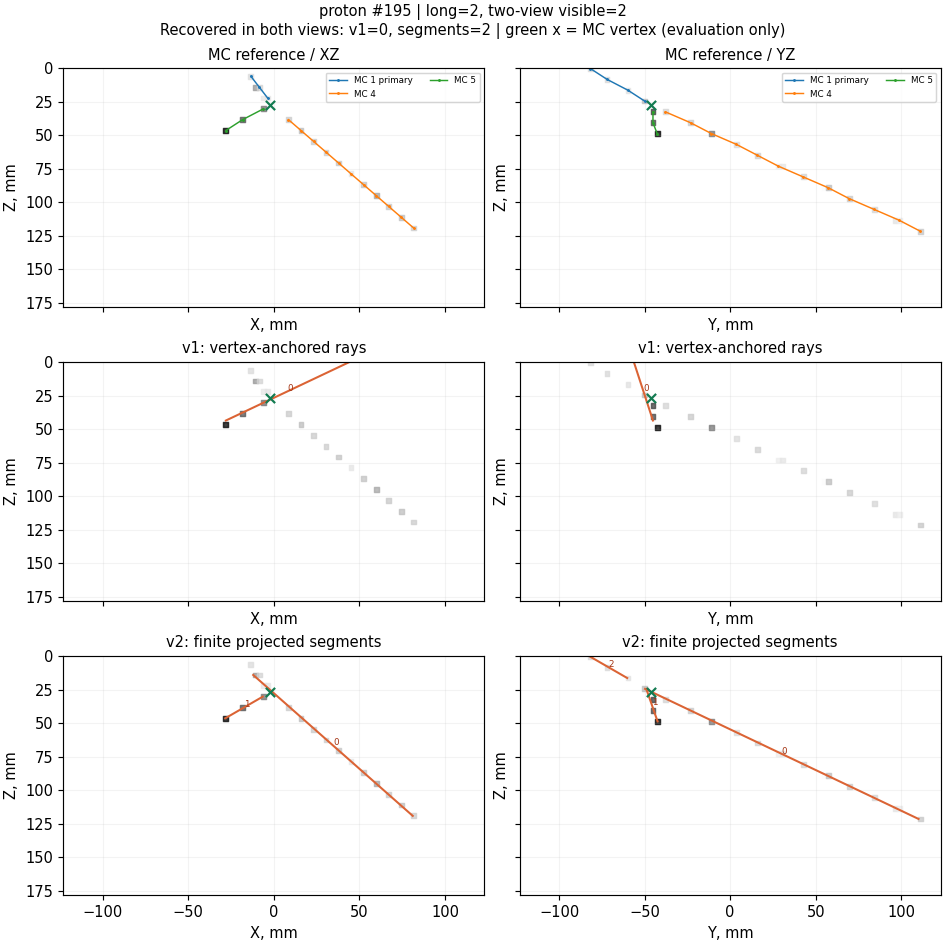

In [3]:
display(Image(filename=str(root/'development/proton_195.png')))

## Пример неоднозначной исходной разметки

Протон 4665: по прежнему правилу есть две длинные вторичные частицы,
но у конца калориметра они не дают двух разделимых ветвей в обоих видах.
Такой случай нельзя автоматически считать однозначной ошибкой детектора.

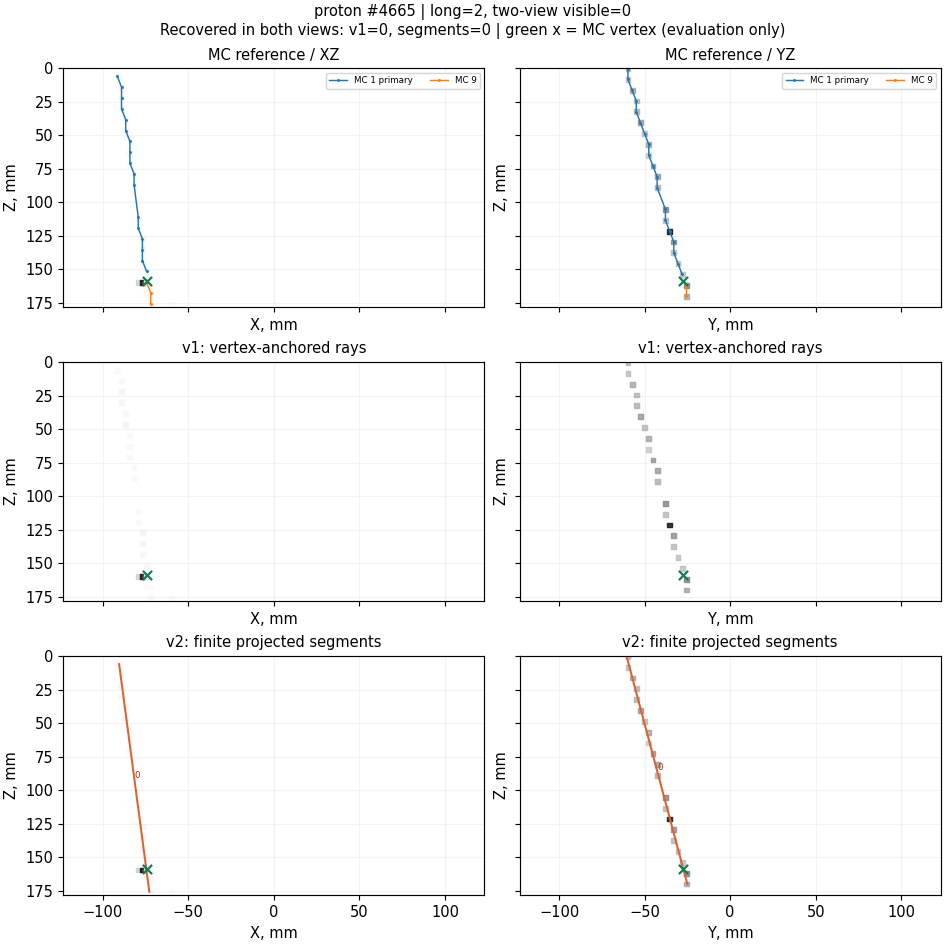

In [4]:
display(Image(filename=str(root/'proton_4665.png')))

## Запуск реконструкции без доступа к истине

```bash
python3 -m reconstruction.run_topology data/raw/calorimeter_response.npy --event-id 195 --out results/topology_example
```

Модуль принимает только две проекции после адаптера. Возможны явные отказы
`no_vertex` и `insufficient_connected_tracks`. Не следует оценивать качество
только на успешно реконструированных событиях: в отчёте есть IoU с нулями
для всех отказов. Изломы могут породить несколько отрезков; их устойчивое
объединение в физические ветви пока не реализовано.